# Sizing Frontier, Objective Choice, and Drift Views

This notebook illustrates the paper's **one-dimensional sizing problem and frontier interpretation**. It combines three related tasks:

1. construct the mean–variance–liquidation frontier;
2. choose an optimal health factor for a penalised objective;
3. study how price-growth drift views change the result.

## 1. Setup

In [1]:
from pathlib import Path
import sys

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "optimal_long_short").exists() and (path / "results").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False})

from optimal_long_short.drift import drift_summary, with_price_drift_view
from optimal_long_short.job_runners.common import load_calibrated_params
from optimal_long_short.risk_report import h0_liquidation_moment_report

params, constraint = load_calibrated_params(ROOT / "results" / "params_WBTC_WETH.json")
T = 1.0 / 12.0
pd.DataFrame(drift_summary(params)).fillna("")

,saved_mu_convention,muX_convention,asset1,asset2,spread
mu_price_growth,price_growth_mu,log_process_muX,0.487093,1.19963,
jump_price_compensator,price_growth_mu,log_process_muX,0.792524,0.942513,
muX_log_process,price_growth_mu,log_process_muX,-0.305431,0.257117,
expected_log_return_drift,price_growth_mu,log_process_muX,0.424502,1.110962,
mu_price_growth_1_minus_2,price_growth_mu,log_process_muX,,,-0.712537
muX_1_minus_2,price_growth_mu,log_process_muX,,,-0.562548
expected_log_return_drift_1_minus_2,price_growth_mu,log_process_muX,,,-0.68646


## 2. Benchmark frontier

We evaluate a grid of feasible health factors. The objective below is illustrative:
\[
\Phi(H_0)=\mathbb E[\Pi_T\mid	au>T]-
rac{lpha}{2}\operatorname{Var}(\Pi_T\mid	au>T)-\delta p_{
m liq}.
\]

In [2]:
alpha, delta = 1.0, 0.5

def compute_sizing_grid(params, H0_values, *, max_moment_order=2):
    """Run the package report and return a DataFrame ready for analysis."""
    rows = h0_liquidation_moment_report(
        params,
        np.log(H0_values),
        b=constraint["b"],
        T=T,
        S10=constraint["S10"],
        S20=constraint["S20"],
        max_moment_order=max_moment_order,
    )
    return pd.DataFrame(rows)

def add_objective(frame, *, alpha, delta):
    """Add the paper's penalised objective to a result DataFrame."""
    out = frame.copy()
    out["objective"] = (
        out["conditional_mean"]
        - 0.5 * alpha * out["conditional_variance"]
        - delta * out["p_liq"]
    )
    return out

H0_grid = np.linspace(constraint["H0_min"] + 0.002, 2.0, 24)
frontier = add_objective(compute_sizing_grid(params, H0_grid), alpha=alpha, delta=delta)
best = frontier.loc[frontier["objective"].idxmax()]

# Tabulate the best candidate and the five highest-scoring grid points.
display(best[["H0", "h0", "initial_leverage", "p_liq", "conditional_mean", "conditional_variance", "objective"]].to_frame("optimal grid value").style.format(precision=5))
frontier.nlargest(5, "objective")[["H0", "initial_leverage", "p_liq", "conditional_mean", "conditional_variance", "objective"]].style.format(precision=5)

,optimal grid value
H0,2.00000
h0,0.69315
initial_leverage,1.63934
p_liq,0.00000
conditional_mean,1.00069
conditional_variance,0.02544
objective,0.98798


,H0,initial_leverage,p_liq,conditional_mean,conditional_variance,objective
23,2.00000,1.63934,0.00000,1.00069,0.02544,0.98798
22,1.95959,1.66125,0.00000,0.99930,0.02617,0.98621
21,1.91917,1.68471,0.00000,0.99781,0.02697,0.98432
20,1.87876,1.70989,0.00001,0.99620,0.02786,0.98227
19,1.83835,1.73700,0.00002,0.99448,0.02883,0.98006


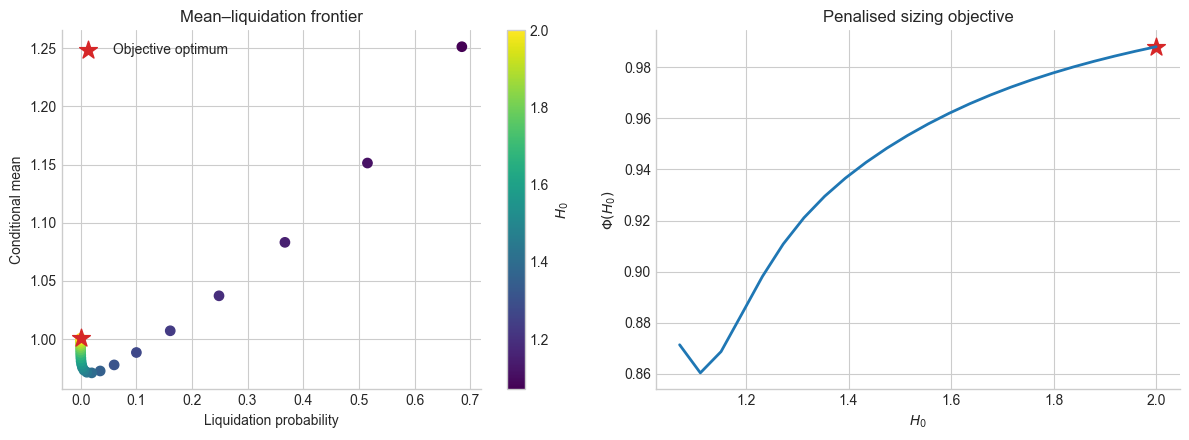

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc = axes[0].scatter(frontier["p_liq"], frontier["conditional_mean"], c=frontier["H0"], cmap="viridis", s=45)
axes[0].scatter(best["p_liq"], best["conditional_mean"], marker="*", s=180, color="tab:red", label="Objective optimum")
axes[0].set(xlabel="Liquidation probability", ylabel="Conditional mean", title="Mean–liquidation frontier")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="$H_0$")

axes[1].plot(frontier["H0"], frontier["objective"], lw=2)
axes[1].scatter(best["H0"], best["objective"], marker="*", s=180, color="tab:red")
axes[1].set(xlabel="$H_0$", ylabel=r"$\Phi(H_0)$", title="Penalised sizing objective")
fig.tight_layout()
plt.show()

## 3. Reuse the computed results for alternative objectives

Once package outputs are in a DataFrame, users can evaluate many preferences without rerunning the moment engine. This table compares optimal grid points for several liquidation penalties.

In [4]:
objective_choices = []
for penalty in [0.0, 0.25, 0.50, 1.00]:
    scored = add_objective(frontier.drop(columns="objective"), alpha=1.0, delta=penalty)
    optimum = scored.loc[scored["objective"].idxmax()]
    objective_choices.append({
        "delta": penalty,
        "optimal H0": optimum["H0"],
        "optimal leverage": optimum["initial_leverage"],
        "liquidation probability": optimum["p_liq"],
        "conditional mean": optimum["conditional_mean"],
        "objective": optimum["objective"],
    })
objective_table = pd.DataFrame(objective_choices).set_index("delta")
objective_table.style.format(precision=5)

,optimal H0,optimal leverage,liquidation probability,conditional mean,objective
delta,,,,,
0.000000,1.07049,3.68509,0.68503,1.25126,1.21392
0.250000,1.07049,3.68509,0.68503,1.25126,1.04267
0.500000,2.00000,1.63934,0.00000,1.00069,0.98798
1.000000,2.00000,1.63934,0.00000,1.00069,0.98797


## 4. Drift-view scenarios

`KouParams.mu1` and `mu2` are annualized price-growth normalizers. The package helper applies views while recomputing the internal log-process drifts safely.

In [5]:
scenarios = {
    "Calibrated": params,
    "Long leg +20%, short leg -20%": with_price_drift_view(params, delta_mu1=0.20, delta_mu2=-0.20),
    "Long leg -20%, short leg +20%": with_price_drift_view(params, delta_mu1=-0.20, delta_mu2=0.20),
}
scenario_rows = []
scenario_curves = {}
H0_scenario = np.linspace(constraint["H0_min"] + 0.002, 2.0, 16)
for name, scenario_params in scenarios.items():
    frame = add_objective(
        compute_sizing_grid(scenario_params, H0_scenario),
        alpha=alpha,
        delta=delta,
    )
    optimum = frame.loc[frame["objective"].idxmax()]
    scenario_rows.append({"scenario": name, **optimum[["H0", "initial_leverage", "p_liq", "conditional_mean", "objective"]].to_dict()})
    scenario_curves[name] = frame

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
scenario_table.style.format(precision=5)

,H0,initial_leverage,p_liq,conditional_mean,objective
scenario,,,,,
Calibrated,2.00000,1.63934,0.00000,1.00069,0.98798
"Long leg +20%, short leg -20%",2.00000,1.63934,0.00000,1.04106,1.02795
"Long leg -20%, short leg +20%",2.00000,1.63934,0.00000,0.96060,0.94826


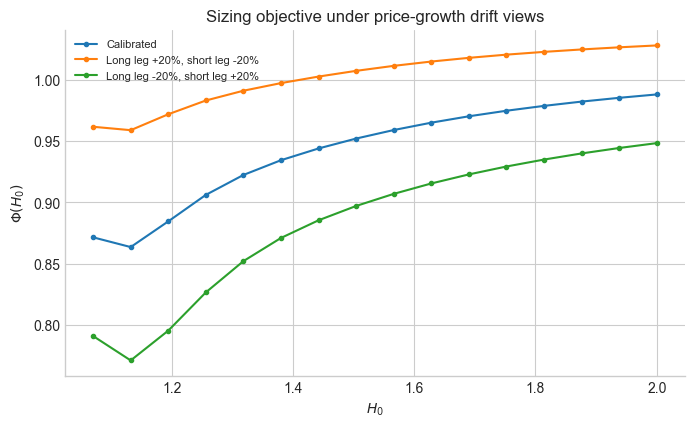

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, frame in scenario_curves.items():
    ax.plot(frame["H0"], frame["objective"], marker="o", ms=3, label=name)
ax.set(xlabel="$H_0$", ylabel=r"$\Phi(H_0)$", title="Sizing objective under price-growth drift views")
ax.legend(fontsize=8)
plt.show()

## 5. Takeaway

The health factor remains the single sizing variable across objectives and drift views. The package separates calibrated dynamics from explicit user views, making scenario analysis transparent.